In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Đọc file gốc
df_raw = pd.read_csv('data_has_Correctly.csv')

# Xem qua dữ liệu
df_raw.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [5]:
# Dùng format cụ thể để parse chính xác
df_raw['Order Placed At'] = pd.to_datetime(df_raw['Order Placed At'], format="%I:%M %p, %B %d %Y", errors='coerce')

# Loại bỏ dòng không parse được
df_raw = df_raw.dropna(subset=['Order Placed At'])

# Kiểm tra lại
df_raw[['Order Placed At']].head()

,Order Placed At
0,2024-09-10 23:38:00
1,2024-09-10 23:34:00
2,2024-09-10 15:52:00
3,2024-09-10 15:45:00
4,2024-09-10 15:04:00


In [7]:
# Loại bỏ các dòng có giá trị thiếu ở những cột quan trọng
df = df_raw.dropna(subset=['Order ID', 'Restaurant ID', 'Order Placed At', 'Items in order', 'KPT duration (minutes)'])



# Loại bỏ các dòng không parse được thời gian
df = df.dropna(subset=['Order Placed At'])

# Kiểm tra lại
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19087 entries, 0 to 19086
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   Restaurant ID                                       19087 non-null  int64         
 1   Restaurant name                                     19087 non-null  object        
 2   Subzone                                             19087 non-null  object        
 3   City                                                19087 non-null  object        
 4   Order ID                                            19087 non-null  int64         
 5   Order Placed At                                     19087 non-null  datetime64[ns]
 6   Order Status                                        19087 non-null  object        
 7   Delivery                                            19087 non-null  object        
 8   Distan

In [8]:
import re

# Đếm số lượng món từ "1x", "2x", ...
def count_items(item_str):
    if pd.isna(item_str):
        return 0
    matches = re.findall(r'(\d+)x', item_str)
    if matches:
        return sum(int(m) for m in matches)
    else:
        return len(str(item_str).split(','))

# Trích xuất tên món từ chuỗi
def extract_item_names(item_str):
    if pd.isna(item_str):
        return []
    items = [re.sub(r'^\s*\d+x\s*', '', i.strip().lower()) for i in item_str.split(',')]
    return items

# Áp dụng vào dataframe
df['num_items'] = df['Items in order'].apply(count_items)
df['item_list'] = df['Items in order'].apply(extract_item_names)

# Trích xuất thời gian
df['hour'] = df['Order Placed At'].dt.hour
df['weekday'] = df['Order Placed At'].dt.weekday

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer

# One-hot encode item_list
mlb = MultiLabelBinarizer()
item_features = pd.DataFrame(mlb.fit_transform(df['item_list']), columns=mlb.classes_, index=df.index)

# Gộp vào dataframe chính
df_features = pd.concat([df, item_features], axis=1)

In [10]:
# Loại outlier theo IQR
Q1 = df_features['KPT duration (minutes)'].quantile(0.25)
Q3 = df_features['KPT duration (minutes)'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_features = df_features[(df_features['KPT duration (minutes)'] >= lower) & (df_features['KPT duration (minutes)'] <= upper)]

# Biến đầu vào: kết hợp các feature dạng số + món ăn
basic_features = ['num_items', 'hour', 'weekday']
item_columns = list(item_features.columns)
X = df_features[basic_features + item_columns]
y = df_features['KPT duration (minutes)']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

MAE: 3.3635899843389074
R2: 0.12727712025060578


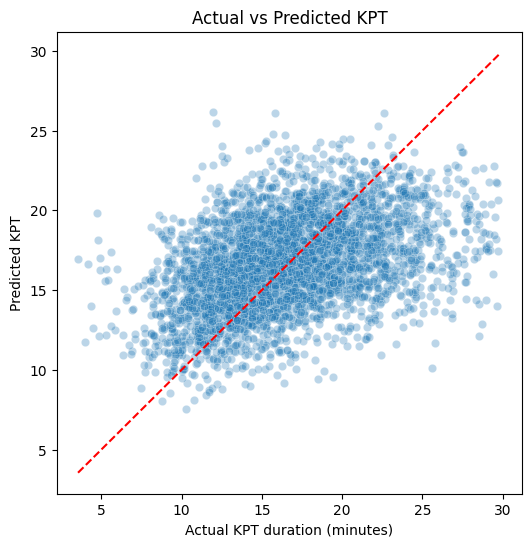

In [14]:
y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual KPT duration (minutes)")
plt.ylabel("Predicted KPT")
plt.title("Actual vs Predicted KPT")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

In [20]:
from sklearn.preprocessing import MultiLabelBinarizer

# Fit MultiLabelBinarizer lại từ dữ liệu train gốc
mlb = MultiLabelBinarizer()
mlb.fit(df['item_list'])  # df là DataFrame gốc bạn dùng để train mô hình

MultiLabelBinarizer()

In [22]:
import pandas as pd
import numpy as np
import re

# Đọc dữ liệu sample
sample_df = pd.read_csv("sample_orders.csv")

# Parse thời gian
sample_df['Order Placed At'] = pd.to_datetime(sample_df['Order Placed At'], format="%I:%M %p, %B %d %Y", errors='coerce')
sample_df = sample_df.dropna(subset=['Order Placed At'])

# Tạo feature từ thời gian
sample_df['hour'] = sample_df['Order Placed At'].dt.hour
sample_df['weekday'] = sample_df['Order Placed At'].dt.weekday

# Hàm đếm số lượng món
def count_items(item_str):
    if pd.isna(item_str):
        return 0
    matches = re.findall(r'(\d+)x', item_str)
    if matches:
        return sum(int(m) for m in matches)
    else:
        return len(str(item_str).split(','))

# Hàm tách tên món
def extract_item_names(item_str):
    if pd.isna(item_str):
        return []
    items = [re.sub(r'^\s*\d+x\s*', '', i.strip().lower()) for i in item_str.split(',')]
    return items

# Áp dụng feature engineering
sample_df['num_items'] = sample_df['Items in order'].apply(count_items)
sample_df['item_list'] = sample_df['Items in order'].apply(extract_item_names)

# Encode món ăn giống lúc train
sample_item_features = pd.DataFrame(mlb.transform(sample_df['item_list']), columns=mlb.classes_, index=sample_df.index)

# Kết hợp với các đặc trưng số
basic_features = ['num_items', 'hour', 'weekday']
X_sample = pd.concat([sample_df[basic_features], sample_item_features], axis=1)

# Đảm bảo không thiếu cột nào
missing_cols = set(X.columns) - set(X_sample.columns)
for col in missing_cols:
    X_sample[col] = 0
X_sample = X_sample[X.columns]  # Sắp xếp đúng thứ tự cột như khi train

# Dự báo
sample_df['Predicted KPT duration (minutes)'] = rf.predict(X_sample)

# Kết quả
sample_df[['Order ID', 'Items in order', 'Predicted KPT duration (minutes)', 'KPT duration (minutes)']]

,Order ID,Items in order,Predicted KPT duration (minutes),KPT duration (minutes)
0,6168884918,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",20.790133,18.35
1,6170707559,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",16.982000,16.95
2,6169375019,1 x Bone in Peri Peri Grilled Chicken,14.645300,14.05
3,6151677434,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",20.962493,19.00
4,6167540897,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",16.789100,15.97
5,7000000001,"1 x Veg Biryani, 1 x Butter Naan",18.373700,13.50
6,7000000002,"1 x Paneer Tikka, 1 x Masala Lemonade",17.255500,17.20
7,7000000003,"1 x Chicken Kathi Roll, 1 x Coke",16.432215,15.00
8,7000000004,"1 x Chicken Biryani, 1 x Raita",16.832675,20.30
9,7000000005,"1 x Idli Sambar, 1 x Filter Coffee",19.677000,10.90


In [35]:
import pandas as pd
import numpy as np

# Bước 1: Lọc các đơn có Rider Wait Time > 7 phút
df_long_wait = df_features[df_features['Rider wait time (minutes)'] > 7].copy()

# Bước 2: Dự đoán KPT cho các đơn này
X_long_wait = df_long_wait[basic_features + item_columns]
df_long_wait['KPT_pred'] = rf.predict(X_long_wait)

# Bước 3: Lấy ngẫu nhiên 50 dòng
df_sample = df_long_wait.sample(n=60, random_state=42).copy()

# Bước 4: Tính thời điểm báo tài xế
df_sample['Suggested_notify_time'] = df_sample['KPT_pred'] -  5 # phút trước khi món xong

# Bước 5: So sánh hiệu quả
df_sample['Actual_KPT'] = df_sample['KPT duration (minutes)']
df_sample['Thời gian chờ sau điều chỉnh'] = df_sample['Actual_KPT'] - df_sample['Suggested_notify_time'] 

# Hiển thị kết quả
df_sample_display = df_sample[[
    'Order ID', 'Items in order', 'Rider wait time (minutes)', 'Actual_KPT', 'KPT_pred',
    'Suggested_notify_time', 'Thời gian chờ sau điều chỉnh'
]]

df_sample_display.head(10)

,Order ID,Items in order,Rider wait time (minutes),Actual_KPT,KPT_pred,Suggested_notify_time,Thời gian chờ sau điều chỉnh
5343,6258921542,1 x Murgh Amritsari Garlic Bread,10.0,15.50,14.247412,9.247412,6.252588
13053,6449825966,1 x Mutton Seekh Pizza,7.8,15.48,15.734150,10.734150,4.745850
16503,6539670248,"1 x Fried Chicken Peri Peri Tender, 1 x AAC Gr...",8.4,18.45,18.107900,13.107900,5.342100
15831,6491028623,"1 x All About Chicken Pizza, 1 x Herbed Potato...",16.8,27.65,25.519200,20.519200,7.130800
13864,6432471062,"2 x Tripple Cheese Pizza, 4 x Bageecha Pizza",14.1,26.32,23.258850,18.258850,8.061150
4906,6264602155,"1 x Bone in Angara Grilled Chicken, 1 x Bone i...",12.2,24.13,22.815200,17.815200,6.314800
16375,6492220400,"1 x Jamaican Chicken Melt, 1 x Fried Chicken T...",13.7,23.30,21.810700,16.810700,6.489300
17980,6545232955,1 x Bone in Smoky Bbq Grilled Chicken,11.5,18.47,18.684470,13.684470,4.785530
583,6160765669,1 x Peri Peri Grilled Chicken Pizza,11.3,18.47,18.886982,13.886982,4.583018
16348,6503110992,"1 x Margherita Pizza, 1 x Just Pepperoni Pide",11.7,16.22,16.204400,11.204400,5.015600
